<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/MEG_HES003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004i2 — 2D Shape-Memory Map in (λ, m)
# ============================================================

# --- Lattice parameters ---
N = 512
L = 50.0
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)

# --- Time parameters ---
dt = 0.002
steps = 6000
t_final = steps * dt

# --- Physical parameters (fixed except λ, m) ---
A = 1.0
sigma = 1.2
k0 = 1.5

# --- Precompute FFT wave numbers (k) ---
k = 2*np.pi * np.fft.fftfreq(N, d=dx)

# --- Initial packet (fixed across scan) ---
psi0 = A * np.exp(-(x**2)/(2*sigma**2)) * np.cos(k0 * x)

# --- Helper functions ---
def compute_width(field):
    norm = np.sum(field**2)
    mean = np.sum(x * field**2) / norm
    var = np.sum((x - mean)**2 * field**2) / norm
    return np.sqrt(var)

def compute_coherence(field, ref):
    num = np.abs(np.sum(field * ref))
    den = np.sqrt(np.sum(field**2) * np.sum(ref**2))
    return num / den

def evolve_and_measure(lam, m, steps=steps, dt=dt):
    """
    For given (λ, m):
      - evolve psi starting from fixed psi0
      - return final coherence with psi0, width, peak amplitude, and final psi(x)
    """
    psi = psi0.copy()
    for step in range(steps):
        # Nonlinear step
        psi_nl = psi - dt * lam * psi**3

        # Linear step via FFT (m-dependent dispersion)
        psi_k = np.fft.fft(psi_nl)
        psi_k *= np.exp(-0.5j * (k**2 / m) * dt)
        psi = np.real(np.fft.ifft(psi_k))

    C_final = compute_coherence(psi, psi0)
    width_final = compute_width(psi)
    peak_final = np.max(np.abs(psi))
    return C_final, width_final, peak_final, psi

# --- Parameter grids ---
lambda_values = np.linspace(0.0, 2.0, 9)   # 0.0 ... 2.0
m_values      = np.linspace(0.5, 2.0, 11)  # 0.5 ... 2.0

n_lam = len(lambda_values)
n_m   = len(m_values)

C_map     = np.zeros((n_lam, n_m))
width_map = np.zeros((n_lam, n_m))
peak_map  = np.zeros((n_lam, n_m))

print("Running QFT2004i2 (λ, m) scan...")
for i, lam in enumerate(lambda_values):
    for j, m_val in enumerate(m_values):
        C_final, w_final, p_final, psi_final = evolve_and_measure(lam, m_val)
        C_map[i, j]     = C_final
        width_map[i, j] = w_final
        peak_map[i, j]  = p_final
        print(f"λ = {lam:.3f}, m = {m_val:.3f} | C_final = {C_final:.4f}, width_final = {w_final:.4f}, peak_final = {p_final:.4f}")

print("Scan complete.")


Running QFT2004i2 (λ, m) scan...
λ = 0.000, m = 0.500 | C_final = 0.9911, width_final = 0.8121, peak_final = 0.8612
λ = 0.000, m = 0.650 | C_final = 0.9963, width_final = 0.7858, peak_final = 0.9082
λ = 0.000, m = 0.800 | C_final = 0.9982, width_final = 0.7711, peak_final = 0.9355
λ = 0.000, m = 0.950 | C_final = 0.9991, width_final = 0.7621, peak_final = 0.9525
λ = 0.000, m = 1.100 | C_final = 0.9995, width_final = 0.7563, peak_final = 0.9636
λ = 0.000, m = 1.250 | C_final = 0.9997, width_final = 0.7523, peak_final = 0.9714
λ = 0.000, m = 1.400 | C_final = 0.9998, width_final = 0.7494, peak_final = 0.9769
λ = 0.000, m = 1.550 | C_final = 0.9999, width_final = 0.7473, peak_final = 0.9810
λ = 0.000, m = 1.700 | C_final = 0.9999, width_final = 0.7457, peak_final = 0.9841
λ = 0.000, m = 1.850 | C_final = 0.9999, width_final = 0.7445, peak_final = 0.9865
λ = 0.000, m = 2.000 | C_final = 0.9999, width_final = 0.7435, peak_final = 0.9884
λ = 0.250, m = 0.500 | C_final = 0.9566, width_final =

Extracting slice at λ=1.000, m=1.250
density shape: (512,)
density min/max: 1.1102230246251565e-16 0.20510729522138382


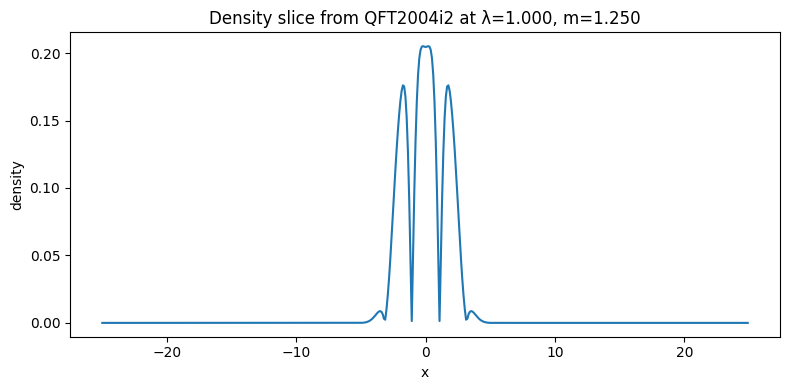

In [2]:
# Pick indices in the lambda_values and m_values arrays
i_lam = 4   # e.g. lambda_values[4] ~ 1.0
j_m   = 5   # e.g. m_values[5]     ~ 1.25

lam_slice = lambda_values[i_lam]
m_slice   = m_values[j_m]

print(f"Extracting slice at λ={lam_slice:.3f}, m={m_slice:.3f}")

C_final, w_final, p_final, psi_final = evolve_and_measure(lam_slice, m_slice)

# Choose what you want to call "density"
# Option A: signed field
# density = psi_final.copy()

# Option B: magnitude (more "density-like")
density = np.abs(psi_final)

print("density shape:", density.shape)
print("density min/max:", density.min(), density.max())

plt.figure(figsize=(8,4))
plt.plot(x, density)
plt.title(f"Density slice from QFT2004i2 at λ={lam_slice:.3f}, m={m_slice:.3f}")
plt.xlabel("x")
plt.ylabel("density")
plt.tight_layout()
plt.show()


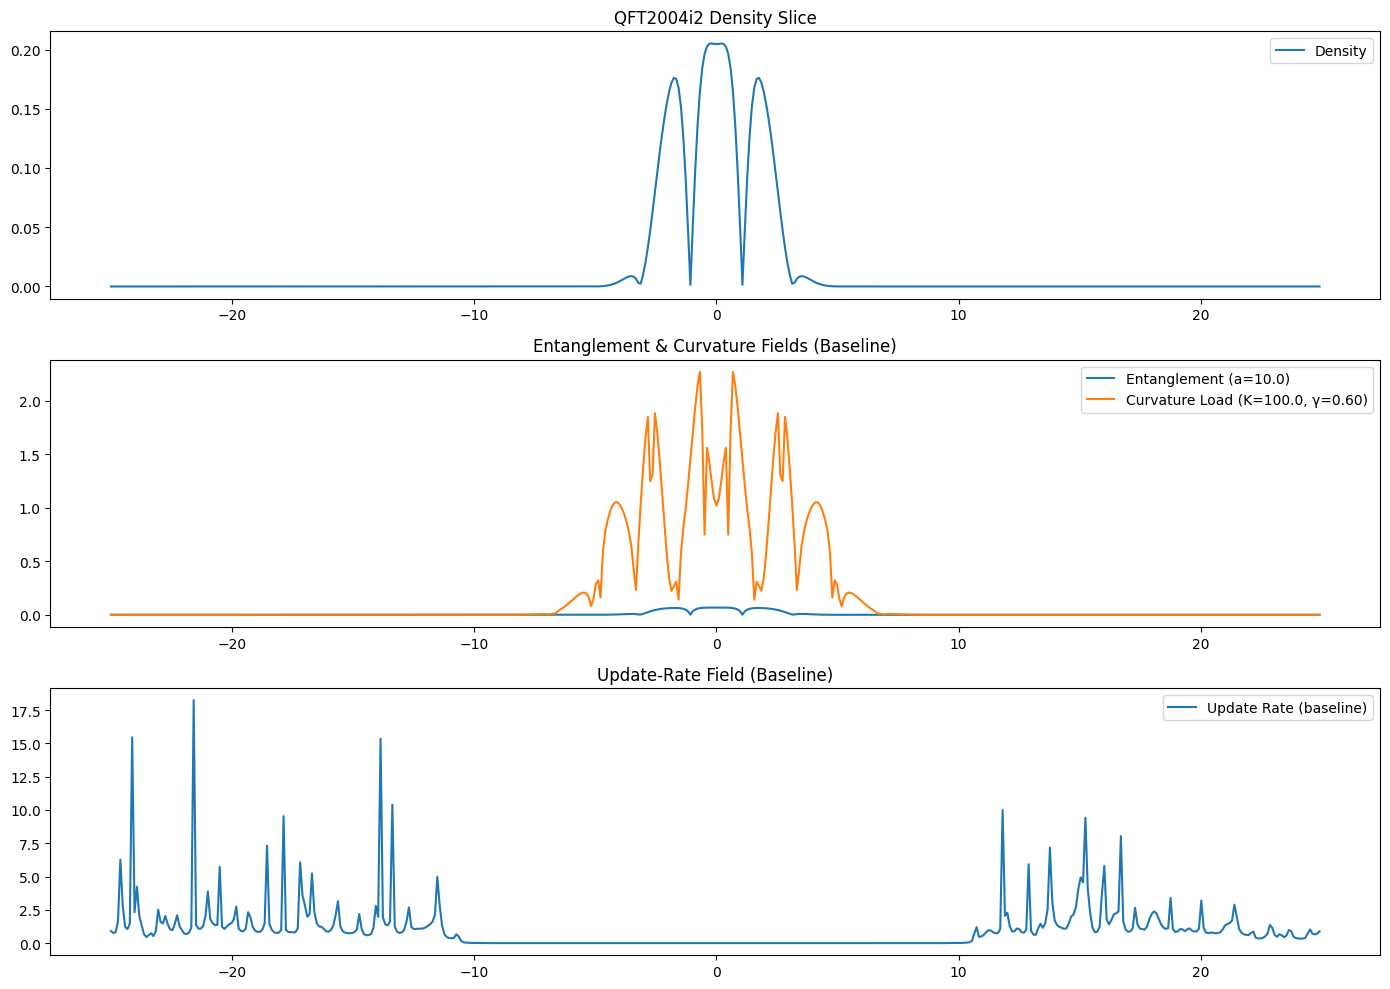

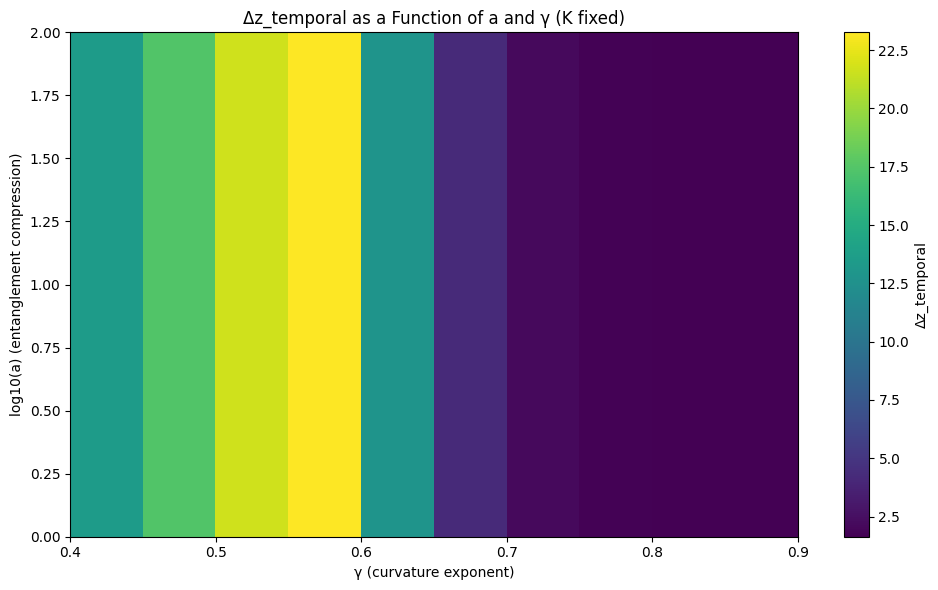

MEG_HES002 on QFT2004i2 slice
Slice at λ=1.000, m=1.250
Baseline (a=10.0, K=100.0, γ=0.6) Δz_temporal: 18.2456
Global extremes over (a, γ) at fixed K:
  MIN Δz_temporal = 1.6371 at a=100, γ=0.900
  MAX Δz_temporal = 23.2599 at a=1, γ=0.567
  • Large Δz → strong Temporal Moiré (big update‑rate contrast).
  • Small Δz → weak Temporal Moiré (nearly uniform update rate).
  • Cosmologically interesting: Δz_temporal ~ O(0.1–1).


In [3]:
# ============================================================
# MEG_HES002 — Softened Entanglement + Smoothed Curvature
# (using 'density' from Cell 2)
# ============================================================

def smooth_field(field, window):
    if window <= 1:
        return field.copy()
    kernel = np.ones(window) / window
    pad = window // 2
    padded = np.pad(field, pad, mode='reflect')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed

smooth_window = 33
density_smooth = smooth_field(density, smooth_window)

def entanglement_map(rho, a):
    return rho / (1 + a * rho)

def curvature_load_field(rho_smooth, K, gamma):
    second_derivative = np.gradient(np.gradient(rho_smooth))
    return K * (np.abs(second_derivative) ** gamma)

def dz_temporal_for_params(a, K, gamma):
    E = entanglement_map(density, a)
    C = curvature_load_field(density_smooth, K, gamma)
    update_rate = 1.0 / (E + C + 1e-9)
    update_rate /= np.mean(update_rate)
    return np.max(update_rate) - np.min(update_rate), update_rate, E, C

a_values = np.logspace(0, 2, 9)      # 1 → 100
gammas   = np.linspace(0.4, 0.9, 10)
K        = 100.0

dz_grid = np.zeros((len(a_values), len(gammas)))
for i, a in enumerate(a_values):
    for j, g in enumerate(gammas):
        dz, _, _, _ = dz_temporal_for_params(a, K, g)
        dz_grid[i, j] = dz

a_baseline     = 10.0
gamma_baseline = 0.6
dz_base, update_rate_base, E_base, C_base = dz_temporal_for_params(a_baseline, K, gamma_baseline)

plt.figure(figsize=(14, 10))

plt.subplot(3,1,1)
plt.plot(x, density, label="Density")
plt.title("QFT2004i2 Density Slice")
plt.legend()

plt.subplot(3,1,2)
plt.plot(x, E_base, label=f"Entanglement (a={a_baseline:.1f})")
plt.plot(x, C_base, label=f"Curvature Load (K={K:.1f}, γ={gamma_baseline:.2f})")
plt.title("Entanglement & Curvature Fields (Baseline)")
plt.legend()

plt.subplot(3,1,3)
plt.plot(x, update_rate_base, label="Update Rate (baseline)")
plt.title("Update‑Rate Field (Baseline)")
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
im = plt.imshow(
    dz_grid,
    origin='lower',
    aspect='auto',
    extent=[gammas[0], gammas[-1], np.log10(a_values[0]), np.log10(a_values[-1])],
    cmap='viridis'
)
plt.colorbar(im, label="Δz_temporal")
plt.xlabel("γ (curvature exponent)")
plt.ylabel("log10(a) (entanglement compression)")
plt.title("Δz_temporal as a Function of a and γ (K fixed)")
plt.tight_layout()
plt.show()

dz_min = np.min(dz_grid)
dz_max = np.max(dz_grid)
min_idx = np.unravel_index(np.argmin(dz_grid), dz_grid.shape)
max_idx = np.unravel_index(np.argmax(dz_grid), dz_grid.shape)

a_min, gamma_min = a_values[min_idx[0]], gammas[min_idx[1]]
a_max, gamma_max = a_values[max_idx[0]], gammas[max_idx[1]]

print("====================================================")
print("MEG_HES002 on QFT2004i2 slice")
print("====================================================")
print(f"Slice at λ={lam_slice:.3f}, m={m_slice:.3f}")
print(f"Baseline (a={a_baseline}, K={K}, γ={gamma_baseline}) Δz_temporal: {dz_base:.4f}")
print("Global extremes over (a, γ) at fixed K:")
print(f"  MIN Δz_temporal = {dz_min:.4f} at a={a_min:.4g}, γ={gamma_min:.3f}")
print(f"  MAX Δz_temporal = {dz_max:.4f} at a={a_max:.4g}, γ={gamma_max:.3f}")
print("====================================================")
print("  • Large Δz → strong Temporal Moiré (big update‑rate contrast).")
print("  • Small Δz → weak Temporal Moiré (nearly uniform update rate).")
print("  • Cosmologically interesting: Δz_temporal ~ O(0.1–1).")
print("====================================================")
